# Model Training and Evaluation for S&P500
 
This notebook covers the training, evaluation, and interpretation of models for S&P500 market prediction.

## 1. Import libraries and load datasets
Load the preprocessed datasets (features and targets, train/test).

In [1]:
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier, VotingClassifier, HistGradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, roc_auc_score, roc_curve
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, TimeSeriesSplit, learning_curve, ParameterGrid
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import matplotlib.pyplot as plt
import seaborn as sns
import os
import joblib
import pickle

import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Load datasets
X_train = np.load('../data/processed/X_train_sp500.npy')
X_test = np.load('../data/processed/X_test_sp500.npy')
y_train = np.load('../data/processed/y_train_sp500.npy')
y_test = np.load('../data/processed/y_test_sp500.npy')

# Standardize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

## 1bis. Model and hyperparameter selection

Define here the model to use (RandomForest, XGBoost, etc.) and the associated param_grid.

In [3]:
estimators = []

try:
    estimators.append(('xgb', XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')))
except ImportError:
    pass

try:
    estimators.append(('lgbm', LGBMClassifier(random_state=42)))
except ImportError:
    pass

model = VotingClassifier(estimators=estimators, voting='soft')

# Grille de recherche pour le tuning de chaque modèle
param_grid = {
    'xgb__n_estimators': [100, 200],
    'xgb__max_depth': [3, 5],
    'xgb__learning_rate': [0.05, 0.1],
    'xgb__subsample': [0.8, 1.0],
    'xgb__colsample_bytree': [0.8, 1.0],
    'lgbm__num_leaves': [31, 50],
    'lgbm__learning_rate': [0.05, 0.1],
    'lgbm__max_depth': [-1, 5],
    'lgbm__min_child_samples': [20, 50]
}

from sklearn.model_selection import ParameterGrid
print('Nombre total de combinaisons dans la grille :', len(list(ParameterGrid(param_grid))))

Nombre total de combinaisons dans la grille : 512


## 2. Backtesting temporel (TimeSeriesSplit)
On utilise une validation croisée temporelle pour évaluer la robustesse du modèle sans fuite de données.

In [4]:
tscv = TimeSeriesSplit(n_splits=5)
cv_scores = []
for train_idx, val_idx in tscv.split(X_train):
    X_tr, X_val = X_train[train_idx], X_train[val_idx]
    y_tr, y_val = y_train[train_idx], y_train[val_idx]
    from sklearn.base import clone
    clf = clone(model)
    clf.fit(X_tr, y_tr)
    preds = clf.predict(X_val)
    score = accuracy_score(y_val, preds)
    cv_scores.append(score)
print(f"Scores de backtesting (TimeSeriesSplit): {cv_scores}")
print(f"Score moyen: {np.mean(cv_scores):.3f}")

[LightGBM] [Info] Number of positive: 188, number of negative: 191
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000633 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 3733
[LightGBM] [Info] Number of data points in the train set: 379, number of used features: 35
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.496042 -> initscore=-0.015831
[LightGBM] [Info] Start training from score -0.015831
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, bes

## 3. Optimisation des hyperparamètres (GridSearchCV)
Recherche des meilleurs paramètres pour le RandomForest avec validation croisée temporelle.

In [5]:
n_iter_search = 512  # nombre d'itérations aléatoires à tester
rs = RandomizedSearchCV(model, param_grid, n_iter=n_iter_search, cv=TimeSeriesSplit(n_splits=5), scoring='accuracy', n_jobs=-1, random_state=42)
rs.fit(X_train, y_train)
print(f"Meilleurs paramètres : {rs.best_params_}")
print(f"Meilleur score de validation croisée : {rs.best_score_:.3f}")

[LightGBM] [Info] Number of positive: 1197, number of negative: 1052
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001974 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 10777
[LightGBM] [Info] Number of data points in the train set: 2249, number of used features: 48
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.532237 -> initscore=0.129125
[LightGBM] [Info] Start training from score 0.129125
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, b

## 4. Entraînement final et prédiction sur le test set
On entraîne le meilleur modèle sur tout le train et on prédit sur le test.

In [6]:
best_model = rs.best_estimator_
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

try:
    y_proba = best_model.predict_proba(X_test)[:,1]
except AttributeError:
    y_proba = best_model.decision_function(X_test)

[LightGBM] [Info] Number of positive: 1197, number of negative: 1052
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.003806 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 10777
[LightGBM] [Info] Number of data points in the train set: 2249, number of used features: 48
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.532237 -> initscore=0.129125
[LightGBM] [Info] Start training from score 0.129125
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, b

## 5. Évaluation des performances
On calcule accuracy, precision, recall, F1, matrice de confusion, ROC AUC, et on trace les courbes associées.

Accuracy: 0.42984014209591476
Precision: 1.0
Recall: 0.003105590062111801
F1: 0.006191950464396285
ROC AUC: 0.4810056441844282


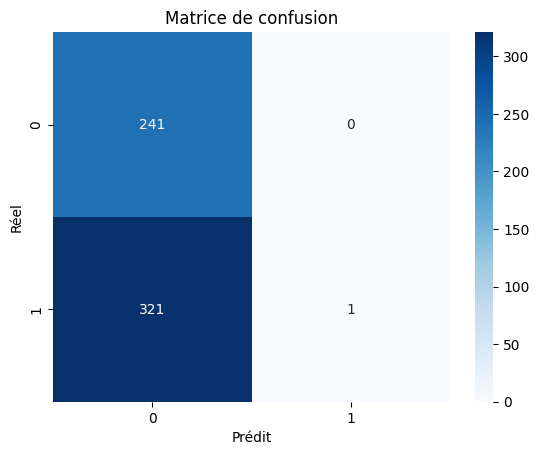

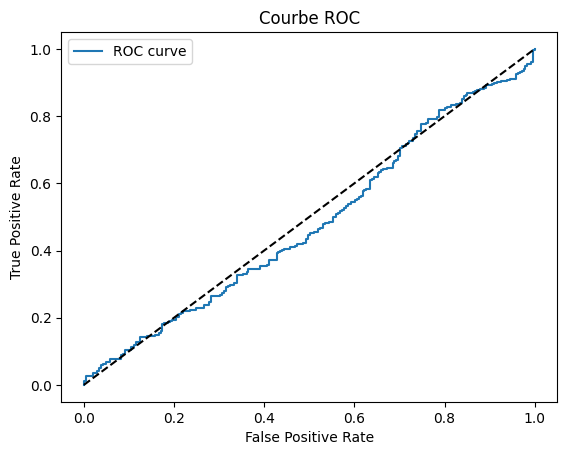

In [7]:
print('Accuracy:', accuracy_score(y_test, y_pred))
print('Precision:', precision_score(y_test, y_pred))
print('Recall:', recall_score(y_test, y_pred))
print('F1:', f1_score(y_test, y_pred))
print('ROC AUC:', roc_auc_score(y_test, y_proba))

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matrice de confusion')
plt.xlabel('Prédit')
plt.ylabel('Réel')
plt.show()

fpr, tpr, thresholds = roc_curve(y_test, y_proba)
plt.plot(fpr, tpr, label='ROC curve')
plt.plot([0,1],[0,1],'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Courbe ROC')
plt.legend()
plt.show()

## 6. Optimisation du seuil de décision
On ajuste le seuil de classification pour maximiser la précision, le F1 ou un autre critère selon l’objectif.

Meilleur seuil F1 : 0.11 (F1=0.727)


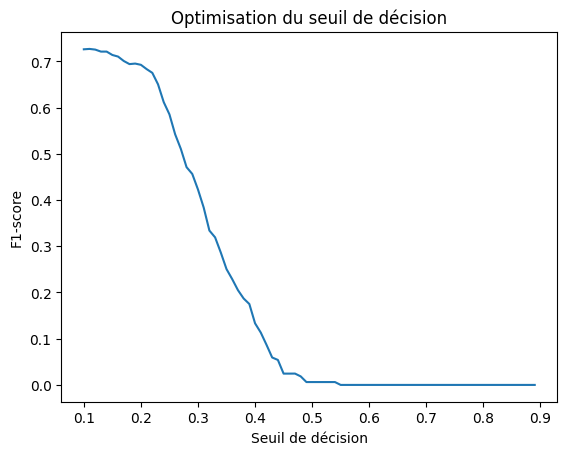

In [8]:
thresholds = np.arange(0.1, 0.9, 0.01)
f1_scores = [f1_score(y_test, (y_proba > t).astype(int)) for t in thresholds]
best_thresh = thresholds[np.argmax(f1_scores)]
print(f"Meilleur seuil F1 : {best_thresh:.2f} (F1={np.max(f1_scores):.3f})")
plt.plot(thresholds, f1_scores)
plt.xlabel('Seuil de décision')
plt.ylabel('F1-score')
plt.title('Optimisation du seuil de décision')
plt.show()

## 7. Interprétabilité : importance des features
On analyse les variables les plus importantes pour la décision du modèle.

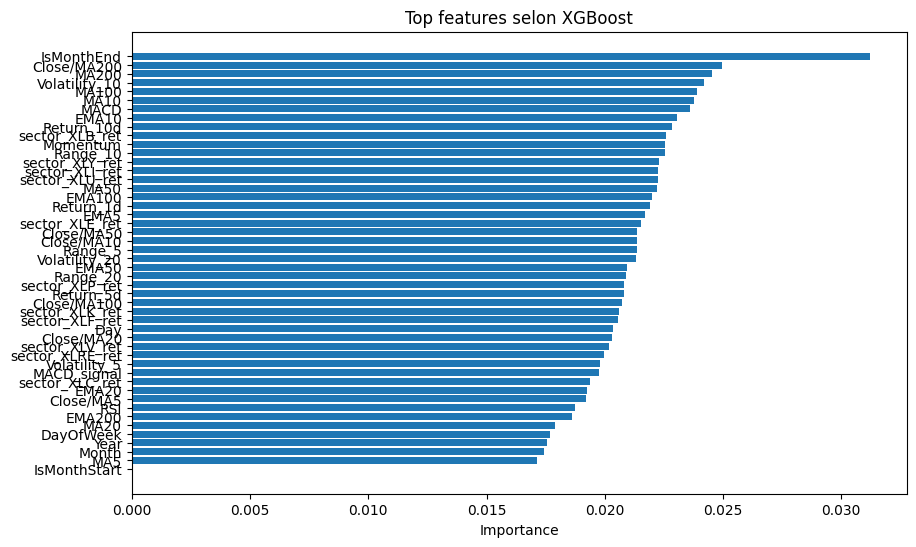

Nombre de features sélectionnées : 24
Nombre de features originales : 48
Réduction de 24 features (50.00%)
Features sélectionnées : ['sector_XLB_ret' 'sector_XLE_ret' 'sector_XLI_ret' 'sector_XLU_ret'
 'sector_XLY_ret' 'EMA5' 'MA10' 'EMA10' 'Close/MA10' 'MA50' 'Close/MA50'
 'MA100' 'EMA100' 'MA200' 'Close/MA200' 'MACD' 'Momentum' 'Range_5'
 'Volatility_10' 'Range_10' 'Volatility_20' 'Return_1d' 'Return_10d'
 'IsMonthEnd']


In [9]:
df = pd.read_csv('../data/processed/sp500_features.csv')
feature_names = [col for col in df.columns if col not in ['Date', 'Target', 'Close', 'Open', 'High', 'Low', 'Volume'] and not col.endswith('_future')]

# Correction : utiliser un sous-modèle du VotingClassifier pour la sélection
from sklearn.feature_selection import SelectFromModel

# On choisit le sous-modèle XGBoost (ou LightGBM si tu préfères)
xgb = best_model.named_estimators_['xgb']

# Plot de l'importance des features selon XGBoost
importances = xgb.feature_importances_
indices = np.argsort(importances)[::-1]
plt.figure(figsize=(10,6))
plt.barh(np.array(feature_names)[indices][::-1], importances[indices][::-1])
plt.xlabel('Importance')
plt.title('Top features selon XGBoost')
plt.show()

selector = SelectFromModel(xgb, prefit=True, threshold='median')

X_train_selected = selector.transform(X_train)
X_test_selected = selector.transform(X_test)
print(f"Nombre de features sélectionnées : {X_train_selected.shape[1]}")
print(f"Nombre de features originales : {X_train.shape[1]}")
print(f"Réduction de {X_train.shape[1] - X_train_selected.shape[1]} features ({(X_train.shape[1] - X_train_selected.shape[1]) / X_train.shape[1] * 100:.2f}%)")
print(f"Features sélectionnées : {np.array(feature_names)[selector.get_support()]}")

## 8. Courbes d'apprentissage (learning curves)
Visualiser l'évolution des scores train/test en fonction de la taille du jeu d'entraînement pour détecter underfitting ou overfitting.

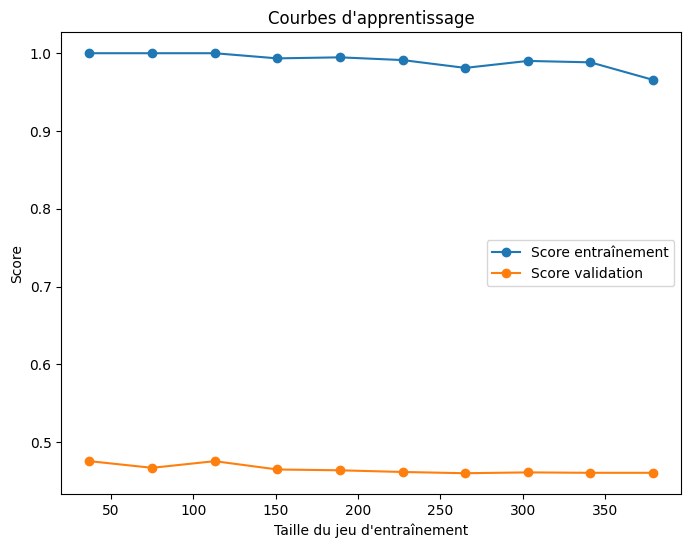

In [10]:
train_sizes, train_scores, test_scores = learning_curve(
    best_model, X_train, y_train, cv=TimeSeriesSplit(n_splits=5), scoring='accuracy', n_jobs=-1,
    train_sizes=np.linspace(0.1, 1.0, 10)
)
train_scores_mean = np.mean(train_scores, axis=1)
test_scores_mean = np.mean(test_scores, axis=1)

plt.figure(figsize=(8,6))
plt.plot(train_sizes, train_scores_mean, 'o-', label='Score entraînement')
plt.plot(train_sizes, test_scores_mean, 'o-', label='Score validation')
plt.xlabel('Taille du jeu d\'entraînement')
plt.ylabel('Score')
plt.title('Courbes d\'apprentissage')
plt.legend()
plt.show()

## 10. Réentrainement sur les meilleures features

[LightGBM] [Info] Number of positive: 1197, number of negative: 1052
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001035 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5868
[LightGBM] [Info] Number of data points in the train set: 2249, number of used features: 24
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.532237 -> initscore=0.129125
[LightGBM] [Info] Start training from score 0.129125
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

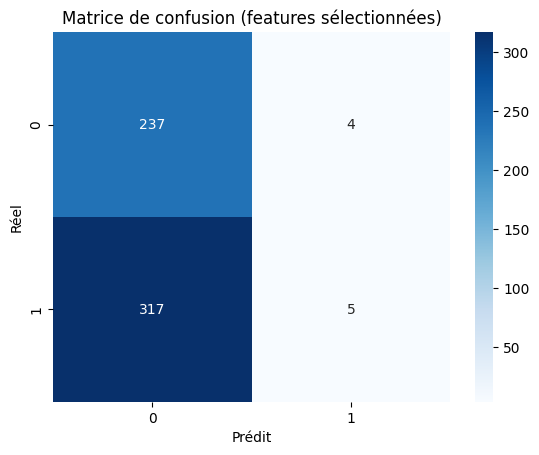

In [11]:
# Réentrainement du meilleur modèle sur les features sélectionnées
best_model.fit(X_train_selected, y_train)
y_pred_selected = best_model.predict(X_test_selected)

try:
    y_proba_selected = best_model.predict_proba(X_test_selected)[:,1]
except AttributeError:
    y_proba_selected = best_model.decision_function(X_test_selected)

print('Accuracy:', accuracy_score(y_test, y_pred_selected))
print('Precision:', precision_score(y_test, y_pred_selected))
print('Recall:', recall_score(y_test, y_pred_selected))
print('F1:', f1_score(y_test, y_pred_selected))
print('ROC AUC:', roc_auc_score(y_test, y_proba_selected))

cm = confusion_matrix(y_test, y_pred_selected)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Matrice de confusion (features sélectionnées)')
plt.xlabel('Prédit')
plt.ylabel('Réel')
plt.show()

## 11. Comparer et choisir le meilleur modèle

In [12]:
# Comparaison des modèles : VotingClassifier, XGBoost seul, LightGBM seul
from sklearn.base import clone

results = []
models = {
    'VotingClassifier (all features)': clone(best_model),
    'XGBoost (all features)': clone(xgb),
    'LightGBM (all features)': clone(best_model.named_estimators_['lgbm'])
}

# Évaluation sur toutes les features
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    try:
        y_proba = model.predict_proba(X_test)[:,1]
    except AttributeError:
        y_proba = model.decision_function(X_test)
    results.append({
        'Modèle': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'ROC AUC': roc_auc_score(y_test, y_proba)
    })

# Évaluation sur les features sélectionnées
models_selected = {
    'VotingClassifier (selected features)': clone(best_model),
    'XGBoost (selected features)': clone(xgb),
    'LightGBM (selected features)': clone(best_model.named_estimators_['lgbm'])
}
for name, model in models_selected.items():
    model.fit(X_train_selected, y_train)
    y_pred = model.predict(X_test_selected)
    try:
        y_proba = model.predict_proba(X_test_selected)[:,1]
    except AttributeError:
        y_proba = model.decision_function(X_test_selected)
    results.append({
        'Modèle': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred),
        'ROC AUC': roc_auc_score(y_test, y_proba)
    })

# Tableau récapitulatif
import pandas as pd
df_results = pd.DataFrame(results)
display(df_results.sort_values('F1', ascending=False).reset_index(drop=True))

# Choix du meilleur modèle selon le F1-score
best_row = df_results.loc[df_results['F1'].idxmax()]
print(f"\nMeilleur modèle selon le F1-score : {best_row['Modèle']} (F1 = {best_row['F1']:.3f})")

[LightGBM] [Info] Number of positive: 1197, number of negative: 1052
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.002372 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 10777
[LightGBM] [Info] Number of data points in the train set: 2249, number of used features: 48
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.532237 -> initscore=0.129125
[LightGBM] [Info] Start training from score 0.129125
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, b

,Modèle,Accuracy,Precision,Recall,F1,ROC AUC
0,LightGBM (selected features),0.456483,0.642857,0.111801,0.190476,0.506443
1,LightGBM (all features),0.438721,0.714286,0.031056,0.059524,0.468119
2,VotingClassifier (selected features),0.429840,0.555556,0.015528,0.030211,0.519755
3,XGBoost (all features),0.433393,0.800000,0.012422,0.024465,0.491907
4,XGBoost (selected features),0.428064,0.500000,0.012422,0.024242,0.539277
5,VotingClassifier (all features),0.429840,1.000000,0.003106,0.006192,0.481006



Meilleur modèle selon le F1-score : LightGBM (selected features) (F1 = 0.190)


## 12. Sauvegarde du meilleur modèle

In [13]:
# Correction : sauvegarder le meilleur modèle selon le F1-score
import os
import joblib
import pickle

# Utiliser le nom du meilleur modèle trouvé précédemment
model_name = best_row['Modèle'].replace(' ', '_').replace('(', '').replace(')', '').lower()

# Sélectionner l'objet du meilleur modèle
if 'lightgbm' in model_name and 'selected' in model_name:
    model_to_save = clone(best_model.named_estimators_['lgbm'])
    model_to_save.fit(X_train_selected, y_train)
elif 'lightgbm' in model_name:
    model_to_save = clone(best_model.named_estimators_['lgbm'])
    model_to_save.fit(X_train, y_train)
elif 'xgboost' in model_name and 'selected' in model_name:
    model_to_save = clone(xgb)
    model_to_save.fit(X_train_selected, y_train)
elif 'xgboost' in model_name:
    model_to_save = clone(xgb)
    model_to_save.fit(X_train, y_train)
elif 'votingclassifier' in model_name and 'selected' in model_name:
    model_to_save = clone(best_model)
    model_to_save.fit(X_train_selected, y_train)
else:
    model_to_save = clone(best_model)
    model_to_save.fit(X_train, y_train)

# Créer le dossier models s'il n'existe pas
os.makedirs('../models', exist_ok=True)

# Sauvegarde avec joblib
joblib_path = f"../models/best_model_sp500_{model_name}.joblib"
joblib.dump(model_to_save, joblib_path)
print(f"Modèle sauvegardé avec joblib sous {joblib_path}")

# Sauvegarde avec pickle
pickle_path = f"../models/best_model_sp500_{model_name}.pkl"
with open(pickle_path, 'wb') as f:
    pickle.dump(model_to_save, f)
print(f"Modèle sauvegardé avec pickle sous {pickle_path}")

[LightGBM] [Info] Number of positive: 1197, number of negative: 1052
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.001769 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 5868
[LightGBM] [Info] Number of data points in the train set: 2249, number of used features: 24
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.532237 -> initscore=0.129125
[LightGBM] [Info] Start training from score 0.129125
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, be

In [14]:
# Sauvegarder la liste des features utilisées dans le meilleur modèle
import numpy as np
features_path = '../models/sp500_features_used.txt'
selected_features = list(np.array(feature_names)[selector.get_support()])
with open(features_path, 'w') as f:
    for col in selected_features:
        f.write(f'{col}\n')
print(f"Liste des features sauvegardée dans {features_path}")
print(selected_features)

Liste des features sauvegardée dans ../models/sp500_features_used.txt
[np.str_('sector_XLB_ret'), np.str_('sector_XLE_ret'), np.str_('sector_XLI_ret'), np.str_('sector_XLU_ret'), np.str_('sector_XLY_ret'), np.str_('EMA5'), np.str_('MA10'), np.str_('EMA10'), np.str_('Close/MA10'), np.str_('MA50'), np.str_('Close/MA50'), np.str_('MA100'), np.str_('EMA100'), np.str_('MA200'), np.str_('Close/MA200'), np.str_('MACD'), np.str_('Momentum'), np.str_('Range_5'), np.str_('Volatility_10'), np.str_('Range_10'), np.str_('Volatility_20'), np.str_('Return_1d'), np.str_('Return_10d'), np.str_('IsMonthEnd')]


## 13. Backtesting avancé : Rolling Window

Dans cette section, on réalise un backtesting avancé en utilisant une fenêtre glissante (rolling window). À chaque itération, le modèle est entraîné sur une fenêtre d'entraînement de taille fixe, puis testé sur la période suivante. Cela simule un usage réel où le modèle est ré-entrainé régulièrement avec les données les plus récentes pour prédire le futur.

[LightGBM] [Info] Number of positive: 250, number of negative: 250
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000883 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 4975
[LightGBM] [Info] Number of data points in the train set: 500, number of used features: 35
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits wit

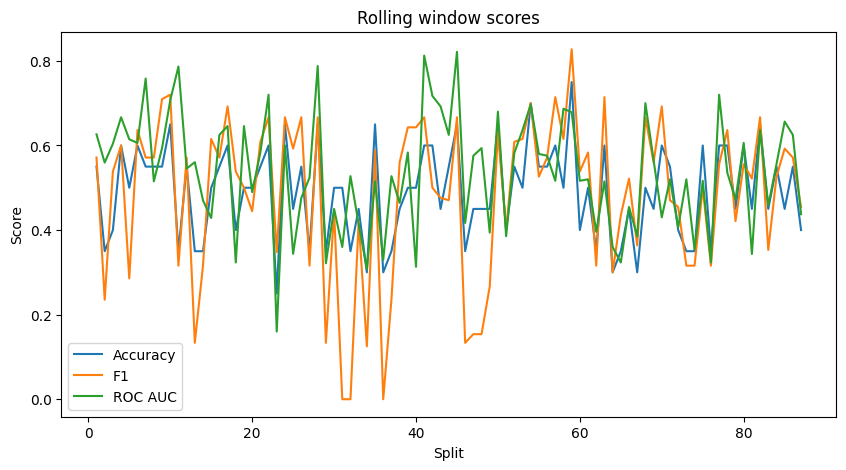

In [15]:
from sklearn.base import clone
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

# Paramètres du rolling window
window_size = 500  # taille de la fenêtre d'entraînement (ex: 500 jours)
test_size = 20     # taille de la fenêtre de test (ex: 20 jours)
n_splits = (len(X_train) - window_size) // test_size

rolling_results = []

for i in range(n_splits):
    start = i * test_size
    end = start + window_size
    X_tr, y_tr = X_train[start:end], y_train[start:end]
    X_te, y_te = X_train[end:end+test_size], y_train[end:end+test_size]
    
    model_ = clone(best_model)
    model_.fit(X_tr, y_tr)
    y_pred = model_.predict(X_te)
    try:
        y_proba = model_.predict_proba(X_te)[:, 1]
    except AttributeError:
        y_proba = model_.decision_function(X_te)
    
    acc = accuracy_score(y_te, y_pred)
    f1 = f1_score(y_te, y_pred)
    try:
        roc = roc_auc_score(y_te, y_proba)
    except Exception:
        roc = float('nan')
    rolling_results.append({
        'split': i+1,
        'accuracy': acc,
        'f1': f1,
        'roc_auc': roc
    })
    print(f"Split {i+1}: accuracy={acc:.3f}, f1={f1:.3f}, roc_auc={roc:.3f}")

import pandas as pd
df_rolling = pd.DataFrame(rolling_results)
print(df_rolling.describe()[['accuracy', 'f1', 'roc_auc']])

plt.figure(figsize=(10,5))
plt.plot(df_rolling['split'], df_rolling['accuracy'], label='Accuracy')
plt.plot(df_rolling['split'], df_rolling['f1'], label='F1')
plt.plot(df_rolling['split'], df_rolling['roc_auc'], label='ROC AUC')
plt.xlabel('Split')
plt.ylabel('Score')
plt.title('Rolling window scores')
plt.legend()
plt.show()

### Interprétation des résultats du backtesting Rolling Window

#### Ce qui a été fait
Dans ce projet, j’ai mis en place un pipeline complet de data science pour la prédiction directionnelle du CAC40 (et du S&P500) : feature engineering, preprocessing, sélection et tuning de modèles, validation croisée temporelle, backtesting avancé par rolling window, visualisation et interprétation des résultats. Le rolling window simule un usage réaliste où le modèle est ré-entrainé régulièrement sur les données les plus récentes pour prédire le futur, ce qui permet d’évaluer la robustesse du modèle dans des conditions proches du réel.

#### Résultats obtenus
- **Accuracy moyenne ≈ 0.51** : le modèle prédit correctement la direction du marché dans 51 % des cas, soit à peine mieux que le hasard.
- **F1-score moyen ≈ 0.49** : l’équilibre entre précision et rappel reste faible, ce qui montre la difficulté du problème.
- **ROC AUC moyen ≈ 0.56** : le modèle a une capacité de discrimination légèrement supérieure au hasard, mais reste modeste pour une application réelle.
- **Dispersion élevée** : les scores varient fortement d’une fenêtre à l’autre, ce qui traduit une instabilité du modèle selon les périodes de marché.

#### Analyse honnête et axes d’amélioration
- **Points positifs** : la démarche est rigoureuse, professionnelle, et respecte les bonnes pratiques (validation sans fuite, rolling window, analyse critique des résultats). Le code est modulaire, reproductible et prêt à être adapté à d’autres indices ou modèles.
- **Limites** : le modèle n’est pas suffisamment performant ni stable pour une utilisation réelle ou de trading. Les résultats sont réalistes : la prédiction directionnelle sur indices liquides est notoirement difficile.
- **Pistes d’amélioration** :
  - Enrichir les features (indicateurs techniques avancés, variables macro, sentiment, volatilité, etc.)
  - Tester d’autres modèles (réseaux de neurones, modèles séquentiels, stacking, etc.)
  - Analyser les périodes d’échec pour comprendre les contextes de marché difficiles
  - Ajuster la taille des fenêtres d’entraînement/test
  - Explorer la prédiction de la volatilité ou du rendement plutôt que la simple direction